In [8]:
import pandas as pd
import os
import tarfile
import urllib.request
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import seaborn as sns

## Ejemplo 2 - Parte 1

Una institución financiera desea desarrollar un modelo que permita clasificar billetes como genuinos o falsos a partir de mediciones físicas obtenidas mediante instrumentos de alta precisión.

Se dispone de un conjunto de datos con 1500 observaciones, donde cada fila representa un billete y contiene las siguientes variables:

- is_genuine: variable objetivo (True = billete genuino, False = billete falso)  
- diagonal: longitud de la diagonal del billete (mm)  
- height_left: altura del lado izquierdo (mm)  
- height_right: altura del lado derecho (mm)  
- margin_low: margen inferior (mm)  
- margin_up: margen superior (mm)  
- length: longitud total del billete (mm)  


a) Cargar la base de datos y describir cada una de las variables que están involucradas.

b) Crear un gráfico de dispersión considerando a las variables diagonal y length.

c) Crear un modelo de regresión logística tomando como variable independiente la longitud total del billete para clasificarlo como genuino o falso.

d) Obtener las diferentes métricas para analizar la bondad del ajuste del modelo.

e) Comprobar si la variable independiente es o no significativa.

f) Realizar el gráfico de probabilidades de la regresión logística.

g) Determinar cómo se clasificaría un billete si su longitud total fuera de 112 mmm y otro de 112.5 mm.

In [20]:
#a) Se cargará la base de datos y se usarán los métodos

data = pd.read_csv("fake_bills.csv", sep=";")
data

,is_genuine,diagonal,height_left,height_right,margin_low,margin_up,length
0,True,171.81,104.86,104.95,4.52,2.89,112.83
1,True,171.46,103.36,103.66,3.77,2.99,113.09
2,True,172.69,104.48,103.50,4.40,2.94,113.16
3,True,171.36,103.91,103.94,3.62,3.01,113.51
4,True,171.73,104.28,103.46,4.04,3.48,112.54
...,...,...,...,...,...,...,...
1495,False,171.75,104.38,104.17,4.42,3.09,111.28
1496,False,172.19,104.63,104.44,5.27,3.37,110.97
1497,False,171.80,104.01,104.12,5.51,3.36,111.95
1498,False,172.06,104.28,104.06,5.17,3.46,112.25


In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   is_genuine    1500 non-null   bool   
 1   diagonal      1500 non-null   float64
 2   height_left   1500 non-null   float64
 3   height_right  1500 non-null   float64
 4   margin_low    1463 non-null   float64
 5   margin_up     1500 non-null   float64
 6   length        1500 non-null   float64
dtypes: bool(1), float64(6)
memory usage: 71.9 KB


In [24]:
data.describe()

,diagonal,height_left,height_right,margin_low,margin_up,length
count,1500.000000,1500.000000,1500.000000,1463.000000,1500.000000,1500.00000
mean,171.958440,104.029533,103.920307,4.485967,3.151473,112.67850
std,0.305195,0.299462,0.325627,0.663813,0.231813,0.87273
min,171.040000,103.140000,102.820000,2.980000,2.270000,109.49000
25%,171.750000,103.820000,103.710000,4.015000,2.990000,112.03000
50%,171.960000,104.040000,103.920000,4.310000,3.140000,112.96000
75%,172.170000,104.230000,104.150000,4.870000,3.310000,113.34000
max,173.010000,104.880000,104.950000,6.900000,3.910000,114.44000


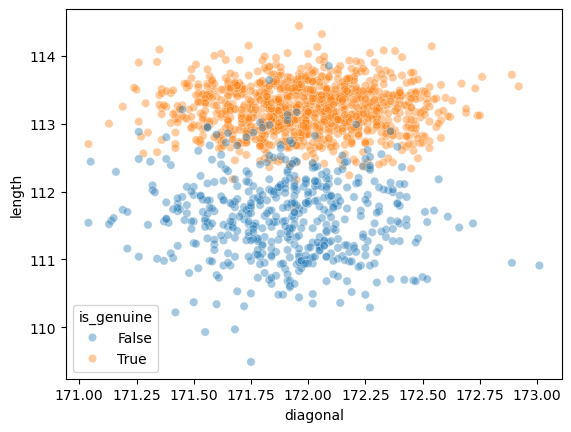

In [26]:
#b) Crear gráfico de dispersión clasificado por is_genuine
plt.figure()
sns.scatterplot(data=data, x="diagonal", y="length", hue="is_genuine", alpha=0.4)
plt.show()

De gráfico se observa que si la longitud total de billete es más grande, entonces tiende a clasificarse como verdadero, en cambio para longitudes pequeñas la probabilidad de ser falso aumenta. Por lo que la longitud tiene relevancia para la clasificación de los billetes.

In [29]:
#c) Creación del modelo de regresión logística

#Se importa la clase LogisticRegression
from sklearn.linear_model import LogisticRegression

x = data["length"].values.reshape(-1,1)

#Crar variable indicadora para default
data["Billete"] = [1 if x is True else 0 for x in data["is_genuine"]]
y = data["Billete"]

logistic_reg = LogisticRegression(penalty=None)
logistic_reg.fit(x,y)

LogisticRegression(penalty=None)

In [31]:
#Obtener los parámetros del modelo
print("El coeficiente de la regresión es %s" %logistic_reg.coef_)

El coeficiente de la regresión es [[6.59673589]]


In [33]:
print("El intercepto de la regresión es %s" %logistic_reg.intercept_)

El intercepto de la regresión es [-741.92691337]


d) Las principales métricas a obtener serán:
 - El accuracy score
 - La matriz de confusión 
 - El valor de la precisión, recall y F1

In [36]:
from sklearn.metrics import accuracy_score

#Obtener el accuracy score
y_pred = logistic_reg.predict(x)
accuracy = accuracy_score(y, y_pred)
print("El accuracy score que se tiene es %s" %accuracy)

El accuracy score que se tiene es 0.9566666666666667


Text(50.722222222222214, 0.5, 'Real')

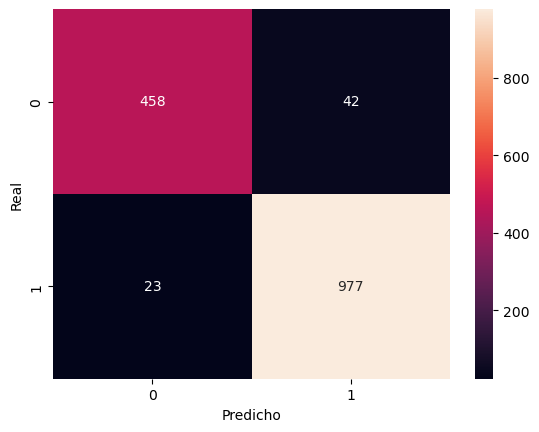

In [38]:
from sklearn.metrics import confusion_matrix

#Obtener la matriz de confusión
cm = confusion_matrix(y, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [40]:
from sklearn.metrics import precision_score, recall_score, f1_score

#Obtener precisión_score, recall y f1
precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)

metricas = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision, recall,f1]})
metricas

,Métricas,Valores
0,Precisión,0.958783
1,Recall,0.977000
2,F1,0.967806


El modelo de clasificación obtuvo un accuracy de 0.9567, lo que significa que clasifica correctamente aproximadamente el 95.67% de los billetes del conjunto de datos evaluado. Esto indica un desempeño bastante alto utilizando la longitud del billete como variable para diferenciar entre billetes falsos y verdaderos.

La matriz de confusión muestra que el modelo realizó una gran cantidad de clasificaciones correctas y pocos errores. En particular, 458 billetes fueron clasificados correctamente en una clase y 977 en la otra. Por otro lado, 42 billetes fueron clasificados incorrectamente como pertenecientes a la clase positiva cuando no lo eran, y 23 fueron clasificados erróneamente como pertenecientes a la clase negativa cuando sí correspondían a ella.

La precisión fue de 0.958783, lo que indica que del total de billetes que el modelo predijo como pertenecientes a la clase positiva, aproximadamente el 95.88% realmente pertenecían a esa clase. Esto refleja que las predicciones positivas del modelo son bastante confiables.

El recall fue de 0.977000, lo que significa que el modelo identificó correctamente el 97.70% de los billetes de la clase positiva. En otras palabras, tiene una alta capacidad para detectar correctamente los billetes de esa categoría.
El F1 score fue de 0.967806, lo cual muestra un equilibrio adecuado entre la precisión y el recall. Este valor confirma que el modelo no solo acierta mucho, sino que además mantiene un buen balance entre identificar correctamente los casos positivos y evitar clasificaciones erróneas.

In [42]:
#e) Comprobar si la variable independiente es significativa

import statsmodels.api as sm

#Añadir el intercepto
X2 = sm.add_constant(x)  

#Ajutar el modelo
est = sm.Logit(y, X2)

#ver el ajuste
est2 = est.fit()
print(est2.summary())

Optimization terminated successfully.
         Current function value: 0.127476
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:                Billete   No. Observations:                 1500
Model:                          Logit   Df Residuals:                     1498
Method:                           MLE   Df Model:                            1
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.7997
Time:                        10:05:36   Log-Likelihood:                -191.21
converged:                       True   LL-Null:                       -954.77
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       -741.9276     48.885    -15.177      0.000    -837.741    -646.114
x1             6.5967      0

El coeficiente de la variable longitud es 6.5967 y su valor p es 0.000, el cual es menor que 0.05. Por lo que se concluye que esta variable tiene un efecto significativo en la probabilidad de que un billete pertenezca a una determinada clase.

Respecto al pseudo $R^2$, su valor es 0.7997. Este resultado indica que el modelo presenta un ajuste bastante alto. Aunque el pseudo $R^2$ en regresión logística no se interpreta exactamente igual que el $R^2$ de la regresión lineal, un valor cercano a 0.80 sugiere que la variable longitud del billete tiene una capacidad explicativa muy fuerte sobre la clasificación de los billetes.

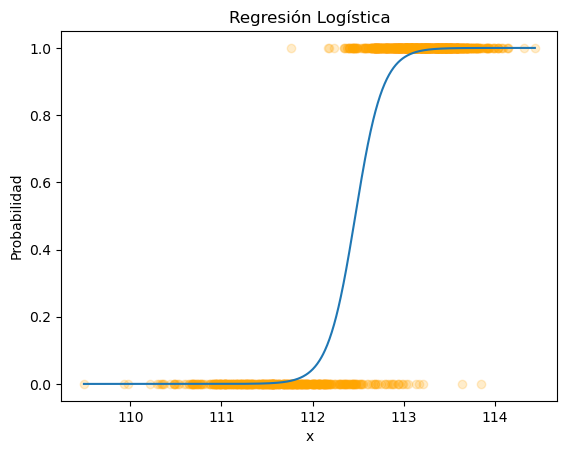

In [44]:
#f) Gráfico de probabilidades

plt.scatter(x, y,alpha=0.2, c ="orange")

#Rango de valores para graficar
x_vals = np.linspace(x.min(), x.max(), 1000).reshape(-1, 1)
y_prob = logistic_reg.predict_proba(x_vals)[:, 1] #Obtener la probabilidad
plt.plot(x_vals, y_prob)

plt.xlabel("x")
plt.ylabel("Probabilidad")
plt.title("Regresión Logística")
plt.show()

In [45]:
#g) Realizar las predicciones 

nuevo_x = np.array([112])
prediccion_1 = logistic_reg.predict(nuevo_x.reshape(-1,1))
print("La clase predicha para una longitud de %s es %s" %(nuevo_x,prediccion_1))

La clase predicha para una longitud de [112] es [0]


In [48]:
#Obtener la probabilidad para la media
proba_1 = logistic_reg.predict_proba(nuevo_x.reshape(-1,1))

#Mostrar las probabilidades
print("La probabilidad de que el billete sea falso es %s" %proba_1[0,0])
print("La probabilidad de que el billete sea verdadero es %s" %proba_1[0,1])

La probabilidad de que el billete sea falso es 0.9565820668660228
La probabilidad de que el billete sea verdadero es 0.04341793313397722


In [50]:
#Realizar las predicciones 

nuevo2_x = np.array([112.5])
prediccion_1 = logistic_reg.predict(nuevo2_x.reshape(-1,1))
print("La clase predicha para una longitud de %s es %s" %(nuevo2_x,prediccion_1))

La clase predicha para una longitud de [112.5] es [1]


In [52]:
#Obtener la probabilidad para la media
proba_2 = logistic_reg.predict_proba(nuevo2_x.reshape(-1,1))

#Mostrar las probabilidades
print("La probabilidad de que el billete sea falso es %s" %proba_2[0,0])
print("La probabilidad de que el billete sea verdadero es %s" %proba_2[0,1])

La probabilidad de que el billete sea falso es 0.44871253958279
La probabilidad de que el billete sea verdadero es 0.55128746041721


## Ejemplo 2 - Parte 2

Se considera el mismo conjunto de datos propuesto en la parte 1. Ahora se pide realizar lo siguiente

a) Realizar un análisis gráfico de las variables cuantitativas mediante histogramas y diagramas de caja y bigote.

b) Se observa que la variable margin_low tiene valores faltantes, por lo que se pide imputar y estandarizar a las variables predictoras.

c) Realizar una partición de los datos en un 25% para la validación y el 75% para el entrenamiento.

d) Crear un modelo de regresión logística considerando a todas las variables independientes la longitud total del billete para clasificarlo como genuino o falso.

e) Obtener las diferentes métricas para analizar la bondad del ajuste del modelo.

f) Comprobar cuales variables son significativas para el modelo creado.

g) Eliminar las variables que no son sigficativas y analizar como va cambiando el pseudo $R^2$.

h) Determinar cómo se clasificaría un billete si se toma como muestra la media de las variables independientes

In [72]:
#Obtener las variables independientes
X_independientes = data.drop(["Billete", "is_genuine"], axis=1)

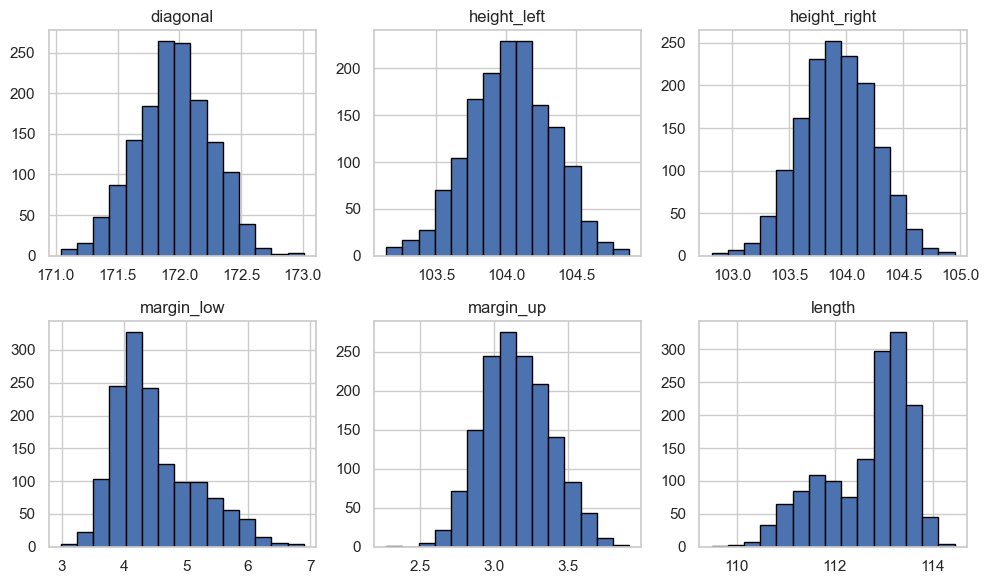

In [90]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for i, var in enumerate(X_independientes.columns):
    plt.subplot(2, 3, i+1)
    plt.hist(X_independientes[var], edgecolor="black",bins=15)
    plt.title(var)

plt.tight_layout()
plt.show()

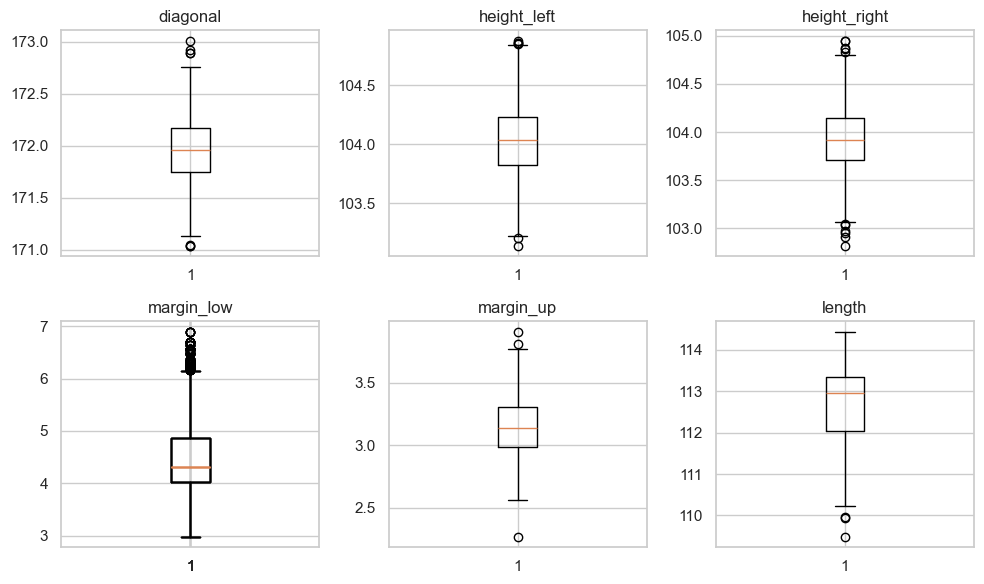

In [104]:
#Dibujar diagrama de cajas

plt.figure(figsize=(10,6))
for i, var in enumerate(X_independientes.columns):
    plt.subplot(2, 3, i+1)
    plt.boxplot(X_independientes[var])
    plt.title(var)

    plt.subplot(2, 3, 4)
    plt.boxplot(X_independientes["margin_low"].dropna())
    plt.title("margin_low")
plt.tight_layout()
plt.show()

In [57]:
#Realizar la imputación y estandarización de los datos.

#Importar el imputador
from sklearn.impute import SimpleImputer
#Importar el estandarizador
from sklearn.preprocessing import StandardScaler
#Importar la clase pipeline
from sklearn.pipeline import Pipeline
#Definir el pipeline
X_pipeline = Pipeline([("imputador", SimpleImputer(strategy="median")), ("std_scaler", StandardScaler()),])

#Aplicar el pipeline
X_independientes_tr = pd.DataFrame(X_pipeline.fit_transform(X_independientes), columns= X_independientes.columns)

In [59]:
X_independientes_tr

,diagonal,height_left,height_right,margin_low,margin_up,length
0,-0.486540,2.774123,3.163240,0.058503,-1.128325,0.173651
1,-1.633729,-2.236535,-0.799668,-1.084932,-0.696799,0.471666
2,2.397823,1.504756,-1.291191,-0.124446,-0.912562,0.551901
3,-1.961498,-0.399294,0.060498,-1.313618,-0.610494,0.953075
4,-0.748754,0.836669,-1.414072,-0.673295,1.417677,-0.158750
...,...,...,...,...,...,...
1495,-0.683201,1.170713,0.767063,-0.093955,-0.265273,-1.602978
1496,0.758981,2.005822,1.596509,1.201938,0.942999,-1.958303
1497,-0.519316,-0.065250,0.613462,1.567837,0.899846,-0.835016
1498,0.332882,0.836669,0.429141,1.049480,1.331372,-0.491152


In [113]:
#Se dividen los datos en 25% para el entrenamiento

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_independientes_tr, y, test_size=0.25, random_state=2026)

In [115]:
#Se creaa el modelo de regresión logística

logistic_reg_b = LogisticRegression(penalty=None)
logistic_reg_b.fit(X_train,y_train)

LogisticRegression(penalty=None)

In [117]:
#Mostrar el intercepto
print("El intercepto para este modelo es %s" %logistic_reg_b.intercept_)

El intercepto para este modelo es [2.01697557]


In [119]:
#Mostrar los coeficientes asociados
coefs = pd.DataFrame({"Variables": X_independientes.columns, "Coeficientes": logistic_reg_b.coef_.flatten()})
coefs

,Variables,Coeficientes
0,diagonal,0.158992
1,height_left,-0.437889
2,height_right,-0.818258
3,margin_low,-3.553955
4,margin_up,-2.128527
5,length,5.042826


In [121]:
#Obtener las métricas

#El accuracy_score
y_pred_b = logistic_reg_b.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_b)
print("El accuracy score que se tiene es %s" %accuracy)

El accuracy score que se tiene es 1.0


Text(47.25, 0.5, 'Real')

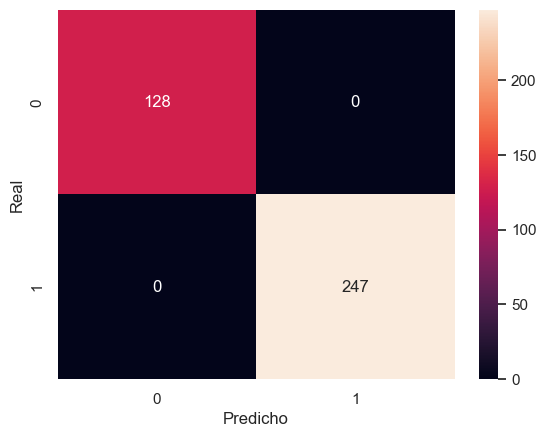

In [135]:
#La matriz de confusión

cm_b = confusion_matrix(y_test, y_pred_b)
sns.heatmap(cm_b, annot=True, fmt="d")
plt.xlabel("Predicho")
plt.ylabel("Real")

In [130]:
#Obtener presicion_score, recall_score, f1_score

precision_b = precision_score(y_test, y_pred_b)
recall_b = recall_score(y_test, y_pred_b)
f1_b = f1_score(y_test, y_pred_b)

metricas_b = pd.DataFrame({"Métricas": ["Precisión", "Recall", "F1"], "Valores": [precision_b, recall_b,f1_b]})
metricas_b

,Métricas,Valores
0,Precisión,1.0
1,Recall,1.0
2,F1,1.0


El modelo de clasificación presenta un desempeño perfecto, ya que obtuvo un accuracy de 1.0. Esto significa que clasificó correctamente el 100% de los billetes del conjunto de prueba, utilizando como variables explicativas la diagonal, la altura del lado izquierdo, la altura del lado derecho, el margen inferior, el margen superior y la longitud total del billete.

La matriz de confusión muestra que no hubo errores de clasificación. En particular, 128 billetes fueron clasificados correctamente en una clase y 247 fueron clasificados correctamente en la otra. No se registraron falsos positivos ni falsos negativos, lo cual indica una separación perfecta entre ambas clases dentro del conjunto evaluado.
La precisión fue de 1.0, lo que significa que todos los billetes que el modelo predijo como pertenecientes a la clase positiva realmente correspondían a esa clase.

El recall también fue de 1.0, indicando que el modelo logró identificar correctamente el 100% de los billetes de la clase positiva. Es decir, no dejó sin detectar ningún caso positivo. El F1 score fue igualmente de 1.0, lo que refleja un equilibrio perfecto entre la precisión y el recall.


In [125]:
import statsmodels.api as sm

#Añadir el intercepto
X2 = sm.add_constant(X_train)  

#Ajutar el modelo
est = sm.Logit(y_train, X2)

#ver el ajuste
est2 = est.fit()
print(est2.summary())

Optimization terminated successfully.
         Current function value: 0.034467
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:                Billete   No. Observations:                 1125
Model:                          Logit   Df Residuals:                     1118
Method:                           MLE   Df Model:                            6
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.9457
Time:                        10:51:00   Log-Likelihood:                -38.775
converged:                       True   LL-Null:                       -713.98
Covariance Type:            nonrobust   LLR p-value:                1.321e-288
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.0433      0.371      5.514      0.000       1.317       2.770
diagonal         0.149

El pseudo $R^2$ es 0.9457, lo cual indica un ajuste excelente del modelo. Aunque esta medida no se interpreta exactamente igual que el $R^2$ en regresión lineal, un valor tan cercano a 1 sugiere que el modelo tiene una capacidad explicativa muy fuerte para diferenciar entre billetes falsos y verdaderos.

Al analizar los p-valores de cada variable, se obtiene lo siguiente:

- La variable diagonal tiene un valor p de 0.653, por lo que no es estadísticamente significativa al nivel de significancia de 0.05.
- La variable height_left tiene un valor p de 0.178, por lo que tampoco resulta estadísticamente significativa al 5%.


In [190]:
#Se eliminarán una por una las variables que no son significativas

#Eliminar la variable diagonal
new_x = X_train.copy()
new_x = new_x.drop("diagonal", axis=1)
X2 = sm.add_constant(new_x)  

#Ajutar el modelo
est = sm.Logit(y_train, X2)

#ver el ajuste
est2 = est.fit()
print(est2.summary())

Optimization terminated successfully.
         Current function value: 0.034557
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:                Billete   No. Observations:                 1125
Model:                          Logit   Df Residuals:                     1119
Method:                           MLE   Df Model:                            5
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.9455
Time:                        15:01:24   Log-Likelihood:                -38.877
converged:                       True   LL-Null:                       -713.98
Covariance Type:            nonrobust   LLR p-value:                8.458e-290
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.0417      0.369      5.534      0.000       1.319       2.765
height_left     -0.442

In [192]:
#Eliminar la variable height_left
new_x = new_x.drop("height_left", axis=1)
X2 = sm.add_constant(new_x)  

#Ajutar el modelo
est = sm.Logit(y_train, X2)

#ver el ajuste
est2 = est.fit()
print(est2.summary())

Optimization terminated successfully.
         Current function value: 0.035401
         Iterations 11
                           Logit Regression Results                           
Dep. Variable:                Billete   No. Observations:                 1125
Model:                          Logit   Df Residuals:                     1120
Method:                           MLE   Df Model:                            4
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                  0.9442
Time:                        15:01:39   Log-Likelihood:                -39.826
converged:                       True   LL-Null:                       -713.98
Covariance Type:            nonrobust   LLR p-value:                1.116e-290
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            2.0273      0.361      5.617      0.000       1.320       2.735
height_right    -0.988

In [194]:
#Realizar la clasificación para la media de cada una de las variables

media_x = np.mean(X_train, axis=0)
array_media = np.array(media_x)

prediccion_media_x = logistic_reg_b.predict(array_media.reshape(1,-1))
print("La clase predicha para la media de las variables es %s" %prediccion_media_x )

La clase predicha para la media de las variables es [1]


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names


In [196]:
proba_2 = logistic_reg_b.predict_proba(array_media.reshape(1,-1))

#Mostrar las probabilidades
print("La probabilidad de que el billete sea falso es %s" %proba_2[0,0])
print("La probabilidad de que el billete sea verdadero es %s" %proba_2[0,1])

La probabilidad de que el billete sea falso es 0.11198101273362682
La probabilidad de que el billete sea verdadero es 0.8880189872663732


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
